In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER
import dask
import intake
#dask.config.set({"logging": "error"})
from pathlib import Path
import glob

import sys
sys.path.append('access-om2-sst-budget/')
import bipolarMhwToolBox as MHW

#import cosima_cookbook as cc
import pandas as pd

%matplotlib inline

In [2]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43965,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38415,Total threads: 2
Dashboard: /proxy/39369/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:37895,


In [3]:
# === Setup ===
base = '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/'
file_pattern = base + "output*/ocean/ocean_daily.nc"
file_list = sorted(glob.glob(file_pattern))

if not file_list:
    raise FileNotFoundError("No matching ocean_daily.nc files found!")

output_dir = Path("/scratch/m35/nm5072/TAS_thresholds/")
output_dir.mkdir(parents=True, exist_ok=True)

zarr_path = output_dir / "TAS_MLD_ready.zarr"

In [4]:
# === Step 1: Preprocess and save to Zarr ===
print("🔄 Preprocessing and saving intermediate file to Zarr...")

ds = xr.open_mfdataset(
    file_list,
    combine="nested",
    concat_dim="time",
    compat="override",
    data_vars="minimal",
    coords="all",
    parallel=True,
    drop_variables=[
        var for var in xr.open_dataset(file_list[0]).data_vars if var != "temp_in_mld"
    ],
    chunks={},  # no chunking at load
)

# Tasman Sea region (Kajtar et al. 2022)
sreg = [135 - 360, 175 - 360, -60, -20]  # [-225, -185, -60, -20]

# Subset data to region and time
temp_mld = ds["temp_in_mld"].sel(
    xt_ocean=slice(sreg[0], sreg[1]),
    yt_ocean=slice(sreg[2], sreg[3]),
    time=slice("1988-01-01", "2018-12-31")
)

# Convert to degrees Celsius and rename
temp = (temp_mld / 1035).rename("temp")

# Wrap in dataset and chunk
ds = temp.to_dataset()
ds = ds.chunk({"time": -1, "yt_ocean": 110, "xt_ocean": 82})

# Save to Zarr
ds.to_zarr(zarr_path, mode="w")
print(f"✅ Saved intermediate Zarr file to: {zarr_path}")

🔄 Preprocessing and saving intermediate file to Zarr...


/jobfs/155904179.gadi-pbs/ipykernel_2640074/1779719369.py:13: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  var for var in xr.open_dataset(file_list[0]).data_vars if var != "temp_in_mld"
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed o

✅ Saved intermediate Zarr file to: /scratch/m35/nm5072/TAS_thresholds/TAS_MLD_ready.zarr


In [5]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:   (xt_ocean: 160, yt_ocean: 220, time: 11323)
Coordinates:
  * xt_ocean  (xt_ocean) float64 1kB -224.9 -224.6 -224.4 ... -185.4 -185.1
  * yt_ocean  (yt_ocean) float64 2kB -59.96 -59.83 -59.71 ... -20.43 -20.19
  * time      (time) datetime64[ns] 91kB 1988-01-01T12:00:00 ... 2018-12-31T1...
Data variables:
    temp      (time, yt_ocean, xt_ocean) float32 2GB dask.array<chunksize=(11323, 110, 82), meta=np.ndarray>

In [6]:
ds = xr.open_zarr(zarr_path)

In [7]:
# === Calculate climatology ===
Seas = MHW.smoothedClima_mhw(ds)
Seas.to_netcdf(output_dir / "om2_025_MLT_clim.nc")

In [8]:
# === Calculate threshold ===
Thresh = MHW.smoothedThresh_mhw(ds)
Thresh.to_netcdf(output_dir / "om2_025_MLT_thresh.nc")

print("✅ Done.")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/

✅ Done.


In [9]:
clim = xr.open_dataset(output_dir / "om2_025_MLT_clim.nc")
threshhold = xr.open_dataset(output_dir / "om2_025_MLT_thresh.nc")

In [10]:
threshhold

<xarray.Dataset> Size: 52MB
Dimensions:    (xt_ocean: 160, yt_ocean: 220, dayofyear: 366)
Coordinates:
  * xt_ocean   (xt_ocean) float64 1kB -224.9 -224.6 -224.4 ... -185.4 -185.1
  * yt_ocean   (yt_ocean) float64 2kB -59.96 -59.83 -59.71 ... -20.43 -20.19
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    temp       (yt_ocean, xt_ocean, dayofyear) float32 52MB ...

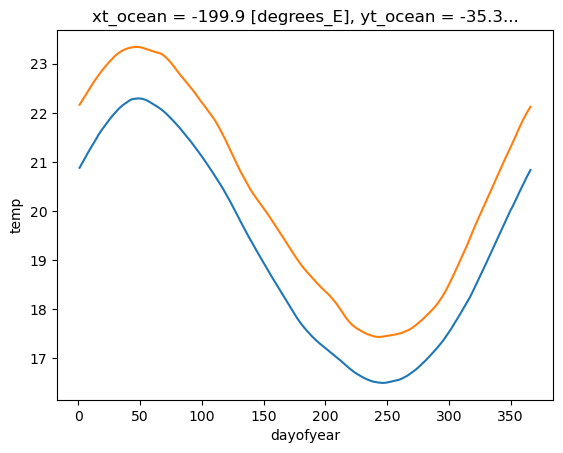

In [11]:
clim.temp.isel(yt_ocean=150,xt_ocean=100).plot()
threshhold.temp.isel(yt_ocean=150,xt_ocean=100).plot()